<a href="https://colab.research.google.com/github/crrbnsn/deepfake-detection-cyb486/blob/main/Crystal_Mouth_Region_Deepfake_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deepfake Detection — Mouth Region Model
### CYB-486/586 | University of Michigan | Dr. Kutub
### Crystal Robinson | rrcrbnsn@umich.edu

## Project Overview
This notebook trains EfficientNet-B4 on mouth region crops from the
FaceForensics++ dataset to detect deepfake manipulation artifacts
in the perioral region. Grad-CAM heatmaps are generated to provide
forensic explainability for each prediction.



Downloads and Imports

In [ ]:
!python download.py -d DeepFakeDetection -c c40 -t videos --server EU2 /content/drive/MyDrive/deepfake_project/dataset
!echo "" | python download.py -d DeepFakeDetection -c c40 -t videos --server EU2 /content/drive/MyDrive/deepfake_project/dataset

In [ ]:
code = '''#!/usr/bin/env python
""" Downloads FaceForensics++ and Deep Fake Detection public data release """
import argparse
import os
import urllib
import urllib.request
import tempfile
import time
import sys
import json
import random
from tqdm import tqdm
from os.path import join

FILELIST_URL = 'misc/filelist.json'
DEEPFEAKES_DETECTION_URL = 'misc/deepfake_detection_filenames.json'
DEEPFAKES_MODEL_NAMES = ['decoder_A.h5', 'decoder_B.h5', 'encoder.h5',]

DATASETS = {
    'original_youtube_videos': 'misc/downloaded_youtube_videos.zip',
    'original_youtube_videos_info': 'misc/downloaded_youtube_videos_info.zip',
    'original': 'original_sequences/youtube',
    'DeepFakeDetection_original': 'original_sequences/actors',
    'Deepfakes': 'manipulated_sequences/Deepfakes',
    'DeepFakeDetection': 'manipulated_sequences/DeepFakeDetection',
    'Face2Face': 'manipulated_sequences/Face2Face',
    'FaceShifter': 'manipulated_sequences/FaceShifter',
    'FaceSwap': 'manipulated_sequences/FaceSwap',
    'NeuralTextures': 'manipulated_sequences/NeuralTextures'
    }
ALL_DATASETS = ['original', 'DeepFakeDetection_original', 'Deepfakes',
                'DeepFakeDetection', 'Face2Face', 'FaceShifter', 'FaceSwap',
                'NeuralTextures']
COMPRESSION = ['raw', 'c23', 'c40']
TYPE = ['videos', 'masks', 'models']
SERVERS = ['EU', 'EU2', 'CA']
'''

with open('/content/download.py', 'w') as f:
    f.write(code)

# Now save to Drive
!cp /content/download.py /content/drive/MyDrive/deepfake_project/download.py
print("✅ done")

✅ done


In [ ]:
!cp /content/download.py /content/drive/MyDrive/deepfake_project/download.py
print("✅ saved to Drive")

✅ saved to Drive


In [ ]:
full_code = '''#!/usr/bin/env python
import argparse
import os
import urllib
import urllib.request
import tempfile
import time
import sys
import json
import random
from tqdm import tqdm
from os.path import join

FILELIST_URL = "misc/filelist.json"
DEEPFEAKES_DETECTION_URL = "misc/deepfake_detection_filenames.json"
DEEPFAKES_MODEL_NAMES = ["decoder_A.h5", "decoder_B.h5", "encoder.h5"]

DATASETS = {
    "original_youtube_videos": "misc/downloaded_youtube_videos.zip",
    "original_youtube_videos_info": "misc/downloaded_youtube_videos_info.zip",
    "original": "original_sequences/youtube",
    "DeepFakeDetection_original": "original_sequences/actors",
    "Deepfakes": "manipulated_sequences/Deepfakes",
    "DeepFakeDetection": "manipulated_sequences/DeepFakeDetection",
    "Face2Face": "manipulated_sequences/Face2Face",
    "FaceShifter": "manipulated_sequences/FaceShifter",
    "FaceSwap": "manipulated_sequences/FaceSwap",
    "NeuralTextures": "manipulated_sequences/NeuralTextures"
}
ALL_DATASETS = ["original", "DeepFakeDetection_original", "Deepfakes",
                "DeepFakeDetection", "Face2Face", "FaceShifter", "FaceSwap",
                "NeuralTextures"]
COMPRESSION = ["raw", "c23", "c40"]
TYPE = ["videos", "masks", "models"]
SERVERS = ["EU", "EU2", "CA"]

def parse_args():
    parser = argparse.ArgumentParser(description="Downloads FaceForensics v2 public data release.")
    parser.add_argument("output_path", type=str, help="Output directory.")
    parser.add_argument("-d", "--dataset", type=str, default="all", choices=list(DATASETS.keys()) + ["all"])
    parser.add_argument("-c", "--compression", type=str, default="raw", choices=COMPRESSION)
    parser.add_argument("-t", "--type", type=str, default="videos", choices=TYPE)
    parser.add_argument("-n", "--num_videos", type=int, default=None)
    parser.add_argument("--server", type=str, default="EU", choices=SERVERS)
    args = parser.parse_args()

    if args.server == "EU":
        server_url = "http://canis.vc.in.tum.de:8100/"
    elif args.server == "EU2":
        server_url = "http://kaldir.vc.in.tum.de/faceforensics/"
    elif args.server == "CA":
        server_url = "http://falas.cmpt.sfu.ca:8100/"
    args.tos_url = server_url + "webpage/FaceForensics_TOS.pdf"
    args.base_url = server_url + "v3/"
    args.deepfakes_model_url = server_url + "v3/manipulated_sequences/Deepfakes/models/"
    return args

def download_files(filenames, base_url, output_path, report_progress=True):
    os.makedirs(output_path, exist_ok=True)
    if report_progress:
        filenames = tqdm(filenames)
    for filename in filenames:
        download_file(base_url + filename, join(output_path, filename))

def reporthook(count, block_size, total_size):
    global start_time
    if count == 0:
        start_time = time.time()
        return
    duration = time.time() - start_time
    progress_size = int(count * block_size)
    speed = int(progress_size / (1024 * duration))
    percent = int(count * block_size * 100 / total_size)
    sys.stdout.write("\\rProgress: %d%%, %d MB, %d KB/s, %d seconds passed" %
                     (percent, progress_size / (1024 * 1024), speed, duration))
    sys.stdout.flush()

def download_file(url, out_file, report_progress=False):
    out_dir = os.path.dirname(out_file)
    if not os.path.isfile(out_file):
        fh, out_file_tmp = tempfile.mkstemp(dir=out_dir)
        f = os.fdopen(fh, "w")
        f.close()
        if report_progress:
            urllib.request.urlretrieve(url, out_file_tmp, reporthook=reporthook)
        else:
            urllib.request.urlretrieve(url, out_file_tmp)
        os.rename(out_file_tmp, out_file)
    else:
        tqdm.write("WARNING: skipping download of existing file " + out_file)

def main(args):
    print("By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use.")
    print("Press any key to continue, or CTRL-C to exit.")
    _ = input("")

    c_datasets = [args.dataset] if args.dataset != "all" else ALL_DATASETS
    c_type = args.type
    c_compression = args.compression
    num_videos = args.num_videos
    output_path = args.output_path
    os.makedirs(output_path, exist_ok=True)

    for dataset in c_datasets:
        dataset_path = DATASETS[dataset]

        if "original_youtube_videos" in dataset:
            print("Downloading original youtube videos.")
            download_file(args.base_url + "/" + dataset_path,
                          out_file=join(output_path, "downloaded_videos.zip"),
                          report_progress=True)
            return

        print("Downloading {} of dataset {}".format(c_type, dataset_path))

        if "DeepFakeDetection" in dataset_path or "actors" in dataset_path:
            filepaths = json.loads(urllib.request.urlopen(args.base_url + "/" + DEEPFEAKES_DETECTION_URL).read().decode("utf-8"))
            if "actors" in dataset_path:
                filelist = filepaths["actors"]
            else:
                filelist = filepaths["DeepFakesDetection"]
        elif "original" in dataset_path:
            file_pairs = json.loads(urllib.request.urlopen(args.base_url + "/" + FILELIST_URL).read().decode("utf-8"))
            filelist = []
            for pair in file_pairs:
                filelist += pair
        else:
            file_pairs = json.loads(urllib.request.urlopen(args.base_url + "/" + FILELIST_URL).read().decode("utf-8"))
            filelist = []
            for pair in file_pairs:
                filelist.append("_".join(pair))
                if c_type != "models":
                    filelist.append("_".join(pair[::-1]))

        if num_videos is not None and num_videos > 0:
            print("Downloading the first {} videos".format(num_videos))
            filelist = filelist[:num_videos]

        dataset_videos_url = args.base_url + "{}/{}/{}/".format(dataset_path, c_compression, c_type)

        if c_type == "videos":
            dataset_output_path = join(output_path, dataset_path, c_compression, c_type)
            print("Output path: {}".format(dataset_output_path))
            filelist = [filename + ".mp4" for filename in filelist]
            download_files(filelist, dataset_videos_url, dataset_output_path)

if __name__ == "__main__":
    args = parse_args()
    main(args)
'''

with open('/content/download.py', 'w') as f:
    f.write(full_code)

!cp /content/download.py /content/drive/MyDrive/deepfake_project/download.py
!wc -l /content/download.py
print("✅ done")

149 /content/download.py
✅ done


In [ ]:
!echo "" | python /content/download.py -d original -c c40 -t videos --server EU2 /content/drive/MyDrive/deepfake_project/dataset

By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use.
Press any key to continue, or CTRL-C to exit.
Output path: /content/drive/MyDrive/deepfake_project/dataset/original_sequences/youtube/c40/videos
100% 1000/1000 [23:55<00:00,  1.44s/it]


In [ ]:
import os

# Create folders for real and fake frames
os.makedirs('/content/drive/MyDrive/deepfake_project/frames/real', exist_ok=True)
os.makedirs('/content/drive/MyDrive/deepfake_project/frames/fake', exist_ok=True)

print("✅ Frame folders created")

✅ Frame folders created


TEST

In [ ]:
import os

real_videos = '/content/drive/MyDrive/deepfake_project/dataset/original_sequences/youtube/c40/videos'
fake_videos = '/content/drive/MyDrive/deepfake_project/dataset/manipulated_sequences/DeepFakeDetection/c40/videos'

real_frames = '/content/drive/MyDrive/deepfake_project/frames/real'
fake_frames = '/content/drive/MyDrive/deepfake_project/frames/fake'

# Get first 5 real videos
real_list = os.listdir(real_videos)[:5]
print("Real videos to process:", real_list)

# Get first 5 fake videos
fake_list = os.listdir(fake_videos)[:5]
print("Fake videos to process:", fake_list)

Real videos to process: ['585.mp4', '599.mp4', '469.mp4', '481.mp4', '183.mp4']
Fake videos to process: ['13_02__podium_speech_happy__2YSYT2N3.mp4', '08_17__podium_speech_happy__ZCEYWYTC.mp4', '10_23__outside_talking_still_laughing__CU6SNBFZ.mp4', '20_13__kitchen_still__NJEO6L5O.mp4', '21_09__kitchen_pan__JEELOMN2.mp4']


In [ ]:
for video_name in real_list:
    video_path = os.path.join(real_videos, video_name)
    # Remove .mp4 and use as folder name
    folder_name = video_name.replace('.mp4', '')
    output_folder = os.path.join(real_frames, folder_name)
    os.makedirs(output_folder, exist_ok=True)

    # Extract 1 frame per second
    !ffmpeg -i "{video_path}" -vf fps=1 "{output_folder}/frame_%04d.png" -loglevel quiet
    print(f"✅ Done: {video_name}")

print("All real videos processed")

✅ Done: 585.mp4
✅ Done: 599.mp4
✅ Done: 469.mp4
✅ Done: 481.mp4
✅ Done: 183.mp4
All real videos processed


In [ ]:
for video_name in fake_list:
    video_path = os.path.join(fake_videos, video_name)
    folder_name = video_name.replace('.mp4', '')
    output_folder = os.path.join(fake_frames, folder_name)
    os.makedirs(output_folder, exist_ok=True)

    !ffmpeg -i "{video_path}" -vf fps=1 "{output_folder}/frame_%04d.png" -loglevel quiet
    print(f"✅ Done: {video_name}")

print("All fake videos processed")

✅ Done: 13_02__podium_speech_happy__2YSYT2N3.mp4
✅ Done: 08_17__podium_speech_happy__ZCEYWYTC.mp4
✅ Done: 10_23__outside_talking_still_laughing__CU6SNBFZ.mp4
✅ Done: 20_13__kitchen_still__NJEO6L5O.mp4
✅ Done: 21_09__kitchen_pan__JEELOMN2.mp4
All fake videos processed


In [ ]:
# Count how many frames we got
real_count = 0
for folder in os.listdir(real_frames):
    folder_path = os.path.join(real_frames, folder)
    frames = os.listdir(folder_path)
    real_count += len(frames)
    print(f"Real - {folder}: {len(frames)} frames")

print(f"\nTotal real frames: {real_count}")

fake_count = 0
for folder in os.listdir(fake_frames):
    folder_path = os.path.join(fake_frames, folder)
    frames = os.listdir(folder_path)
    fake_count += len(frames)
    print(f"Fake - {folder}: {len(frames)} frames")

print(f"\nTotal fake frames: {fake_count}")

Real - 585: 12 frames
Real - 599: 13 frames
Real - 469: 14 frames
Real - 481: 14 frames
Real - 183: 13 frames

Total real frames: 66
Fake - 13_02__podium_speech_happy__2YSYT2N3: 41 frames
Fake - 08_17__podium_speech_happy__ZCEYWYTC: 44 frames
Fake - 10_23__outside_talking_still_laughing__CU6SNBFZ: 32 frames
Fake - 20_13__kitchen_still__NJEO6L5O: 37 frames
Fake - 21_09__kitchen_pan__JEELOMN2: 27 frames

Total fake frames: 181


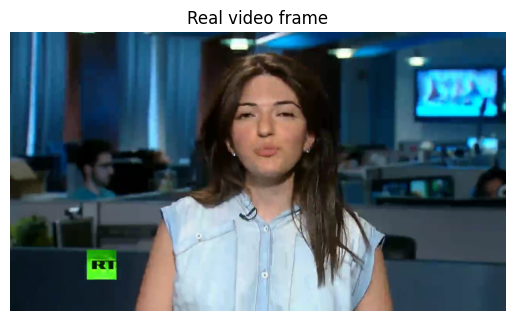

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Pick one real frame to look at
real_folder = os.path.join(real_frames, '585')
first_frame = os.path.join(real_folder, 'frame_0001.png')

img = Image.open(first_frame)
plt.imshow(img)
plt.title("Real video frame")
plt.axis('off')
plt.show()

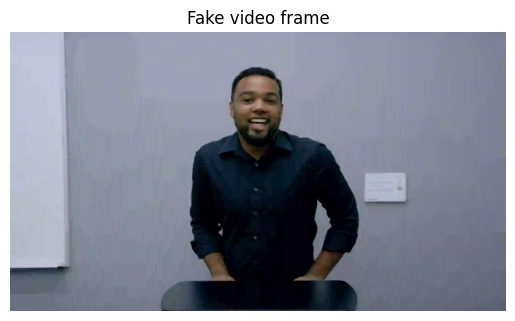

In [ ]:
fake_folder = os.path.join(fake_frames, '13_02__podium_speech_happy__2YSYT2N3')
first_fake_frame = os.path.join(fake_folder, 'frame_0001.png')

img = Image.open(first_fake_frame)
plt.imshow(img)
plt.title("Fake video frame")
plt.axis('off')
plt.show()

Setup & Installation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q facenet-pytorch
!pip install -q ttach
!pip install -q "numpy==1.26.4" "Pillow==9.5.0" grad-cam --no-deps
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q scikit-learn pandas scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 131.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Imports

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
import io

from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

Running on: cuda


Load Models

In [ ]:
weights = EfficientNet_B4_Weights.DEFAULT
model = efficientnet_b4(weights=weights).eval().to(device)
print(f"✅ Model loaded")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 145MB/s]


✅ Model loaded


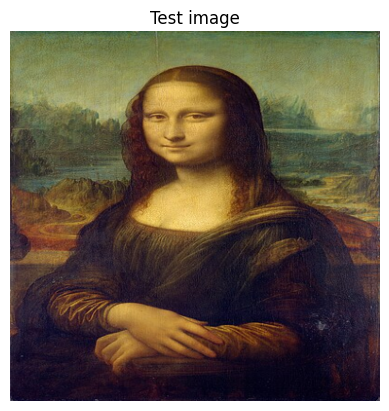

In [ ]:
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg/402px-Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg"

response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
img_pil = Image.open(io.BytesIO(response.content)).convert("RGB").resize((380, 380))
img_np = np.array(img_pil) / 255.0

plt.imshow(img_np)
plt.title("Test image")
plt.axis('off')
plt.show()

Run Grad Cam

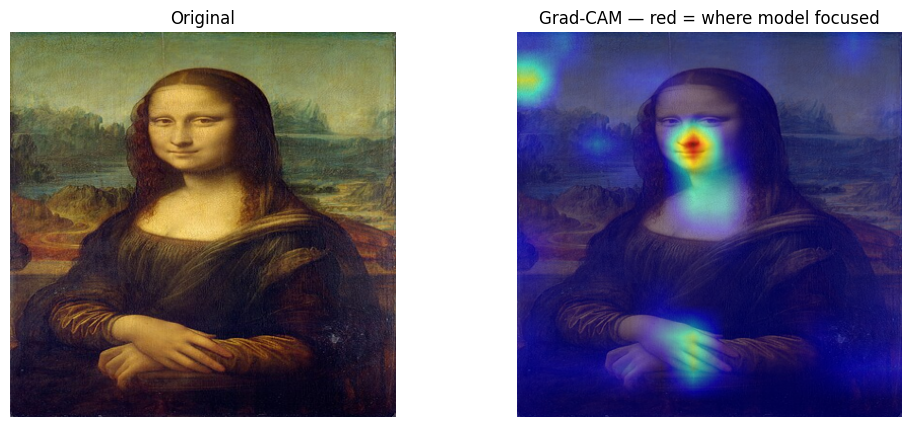

In [ ]:
input_tensor = preprocess_image(
    img_np.astype(np.float32),
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
).to(device)

target_layers = [model.features[-1]]

with GradCAM(model=model, target_layers=target_layers) as cam:
    targets = [ClassifierOutputTarget(956)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

visualization = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_np)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM — red = where model focused")
axes[1].axis('off')
plt.show()

Mouth Region Cropping (MTCNN)

In [1]:
!pip install -q facenet-pytorch #Install MTCNN
print("✅ MTCNN installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124

In [7]:
!pip install -q "Pillow==10.2.0" facenet-pytorch
print("Pillow installed")


Pillow installed


In [ ]:
!pip install -q facenet-pytorch #Install MTCNN
print("✅ MTCNN installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124

In [1]:
#all the mouth cropping

import torch
import numpy as np
from PIL import Image
from facenet_pytorch import MTCNN

device = "cuda" if torch.cuda.is_available() else "cpu"
mtcnn = MTCNN(keep_all=False, device=device)

real_frames = '/content/drive/MyDrive/deepfake_project/frames/real'
fake_frames = '/content/drive/MyDrive/deepfake_project/frames/fake'

crop_real = '/content/drive/MyDrive/deepfake_project/crops/real'
crop_fake = '/content/drive/MyDrive/deepfake_project/crops/fake'
os.makedirs(crop_real, exist_ok=True)
os.makedirs(crop_fake, exist_ok=True)

MOUTH_PAD = 30  # pixels of padding around mouth landmarks

def extract_mouth_crop(img_pil):
    """
    Returns a cropped PIL image of the mouth region, or None if no face detected.
    MTCNN landmarks order: [left_eye, right_eye, nose, mouth_left, mouth_right]
    """
    boxes, probs, landmarks = mtcnn.detect(img_pil, landmarks=True)
    if landmarks is None:
        return None
    lm = landmarks[0]
    mouth_left  = lm[3]
    mouth_right = lm[4]
    x1 = int(min(mouth_left[0], mouth_right[0])) - MOUTH_PAD
    x2 = int(max(mouth_left[0], mouth_right[0])) + MOUTH_PAD
    y1 = int(min(mouth_left[1], mouth_right[1])) - MOUTH_PAD
    y2 = int(max(mouth_left[1], mouth_right[1])) + MOUTH_PAD
    # Clamp to image bounds
    w, h = img_pil.size
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)
    if x2 <= x1 or y2 <= y1:
        return None
    return img_pil.crop((x1, y1, x2, y2))

def process_frames(src_root, dst_root, label):
    saved, skipped = 0, 0
    for video_folder in os.listdir(src_root):
        folder_path = os.path.join(src_root, video_folder)
        if not os.path.isdir(folder_path):
            continue
        for frame_file in os.listdir(folder_path):
            if not frame_file.endswith('.png'):
                continue
            frame_path = os.path.join(folder_path, frame_file)
            img  = Image.open(frame_path).convert('RGB')
            crop = extract_mouth_crop(img)
            if crop is None:
                skipped += 1
                continue
            crop = crop.resize((128, 128))
            out_name = f"{video_folder}__{frame_file}"
            crop.save(os.path.join(dst_root, out_name))
            saved += 1
    print(f"  {label}: {saved} crops saved, {skipped} frames skipped (no face found)")

print("Processing real frames...")
process_frames(real_frames, crop_real, "REAL")
print("Processing fake frames...")
process_frames(fake_frames, crop_fake, "FAKE")
print("\n✅ All mouth crops saved")


NameError: name 'os' is not defined

In [ ]:
import matplotlib.pyplot as plt   #visual of cropping

crop_files_real = os.listdir(crop_real)[:3]
crop_files_fake = os.listdir(crop_fake)[:3]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i, f in enumerate(crop_files_real):
    img = Image.open(os.path.join(crop_real, f))
    axes[0][i].imshow(img)
    axes[0][i].set_title("REAL", fontsize=10)
    axes[0][i].axis('off')
for i, f in enumerate(crop_files_fake):
    img = Image.open(os.path.join(crop_fake, f))
    axes[1][i].imshow(img)
    axes[1][i].set_title("FAKE", fontsize=10)
    axes[1][i].axis('off')
plt.suptitle("Mouth Region Crops — verify faces are visible")
plt.tight_layout()
plt.show()


# Datasets and Dataloader

Imports

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from PIL import Image
import os, random
import numpy as np
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

In [ ]:
#Building the file list and split 70/15/15
crop_real = '/content/drive/MyDrive/deepfake_project/crops/real'
crop_fake = '/content/drive/MyDrive/deepfake_project/crops/fake'

real_files = [(os.path.join(crop_real, f), 0) for f in os.listdir(crop_real)]
fake_files = [(os.path.join(crop_fake, f), 1) for f in os.listdir(crop_fake)]
all_files  = real_files + fake_files
random.shuffle(all_files)

paths  = [x[0] for x in all_files]
labels = [x[1] for x in all_files]

Model Training

In [ ]:
# 70% train, 15% val, 15% test — stratified so class ratio is preserved
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=42)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42)

print(f"Train : {len(train_paths)} images")
print(f"Val   : {len(val_paths)}   images")
print(f"Test  : {len(test_paths)}  images")
print(f"Train real: {train_labels.count(0)} | Train fake: {train_labels.count(1)}")

In [ ]:
Dataset class and DataLoaders ---
class MouthCropDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

        # Training augmentations (flips + color jitter to improve generalization)
train_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# Validation / test — no augmentation
val_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = MouthCropDataset(train_paths, train_labels, train_tf)
val_ds   = MouthCropDataset(val_paths,   val_labels,   val_tf)
test_ds  = MouthCropDataset(test_paths,  test_labels,  val_tf)

# Weighted sampler — compensates for real/fake class imbalance
class_counts = [train_labels.count(0), train_labels.count(1)]
weights  = [1.0 / class_counts[l] for l in train_labels]
sampler  = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False)
print("✅ DataLoaders ready")

Model Building

In [ ]:
weights_pt = EfficientNet_B4_Weights.DEFAULT
model = efficientnet_b4(weights=weights_pt)

# Replace the classifier head: 1792 features -> 2 classes (real=0, fake=1)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(1792, 2)
)

# Freeze all layers except the last feature block and classifier
# This keeps early ImageNet features intact and only fine-tunes the top
for name, param in model.named_parameters():
    if "features.8" not in name and "classifier" not in name:
        param.requires_grad = False

model = model.to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model ready — trainable parameters: {trainable:,}")

In [ ]:
#loop

import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

EPOCHS = 10
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    running_loss = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # --- Validate ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            val_loss += criterion(out, lbls).item()
            preds     = out.argmax(dim=1)
            correct  += (preds == lbls).sum().item()
            total    += lbls.size(0)

    val_acc = correct / total
    scheduler.step()

    history["train_loss"].append(running_loss / len(train_loader))
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_acc"].append(val_acc)

    # Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   '/content/drive/MyDrive/deepfake_project/best_model.pth')
        print(f"  ✅ New best saved — Val Acc: {val_acc:.4f}")

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.4f}")

In [ ]:
#plot training curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_acc"], label="Val Accuracy", color="green")
axes[1].set_title("Validation Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()



FINE-TUNE EFFICIENTNET-B4

Evaluation — AUC-ROC, F1, Accuracy

In [ ]:
# Load best model run on test set
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import torch.nn.functional as F

# Load best saved checkpoint
model.load_state_dict(
    torch.load('/content/drive/MyDrive/deepfake_project/best_model.pth',
               map_location=device)
)
model.eval()

all_preds, all_probs, all_labels_eval = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs  = imgs.to(device)
        out   = model(imgs)
        probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()  # probability of FAKE
        preds = out.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels_eval.extend(lbls.numpy())

accuracy = accuracy_score(all_labels_eval, all_preds)
f1       = f1_score(all_labels_eval, all_preds)
auc      = roc_auc_score(all_labels_eval, all_probs)

print("=" * 40)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print("=" * 40)



In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm   = confusion_matrix(all_labels_eval, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(all_labels_eval, all_probs)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="steelblue", linewidth=2)
axes[1].plot([0, 1], [0, 1], '--', color='gray', label="Random baseline")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

# GRAD-CAM on Trained Model

In [ ]:
# --- Cell 6.1 — Grad-CAM on test samples ---
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

target_layers = [model.features[-1]]

def run_gradcam(img_path, true_label, ax_orig, ax_cam):
    img_pil = Image.open(img_path).convert("RGB").resize((128, 128))
    img_np  = np.array(img_pil) / 255.0

    input_tensor = preprocess_image(
        img_np.astype(np.float32),
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ).to(device)

    with GradCAM(model=model, target_layers=target_layers) as cam:
        targets       = [ClassifierOutputTarget(1)]  # class 1 = FAKE
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    visualization = show_cam_on_image(
        img_np.astype(np.float32), grayscale_cam, use_rgb=True
    )
    label_str = "FAKE" if true_label == 1 else "REAL"
    ax_orig.imshow(img_np)
    ax_orig.set_title(f"Original ({label_str})")
    ax_orig.axis('off')
    ax_cam.imshow(visualization)
    ax_cam.set_title("Grad-CAM heatmap")
    ax_cam.axis('off')

# Show 1 real and 2 fake samples
samples = (
    [(p, l) for p, l in zip(test_paths, test_labels) if l == 0][:1] +
    [(p, l) for p, l in zip(test_paths, test_labels) if l == 1][:2]
)

fig, axes = plt.subplots(len(samples), 2, figsize=(8, 4 * len(samples)))
for i, (path, label) in enumerate(samples):
    run_gradcam(path, label, axes[i][0], axes[i][1])

plt.suptitle("Grad-CAM — Red regions = where model detected manipulation artifacts",
             fontsize=11)
plt.tight_layout()
plt.show()

DCT Spectral

In [ ]:
# --- Cell 7.1 — Average DCT spectrum: real vs fake ---
from scipy.fftpack import dct
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def compute_dct_spectrum(img_path):
    """Returns log-magnitude 2D DCT of a grayscale image."""
    img    = Image.open(img_path).convert('L').resize((128, 128))
    img_np = np.array(img, dtype=np.float32)
    dct_2d = dct(dct(img_np, axis=0, norm='ortho'), axis=1, norm='ortho')
    return np.log(np.abs(dct_2d) + 1e-8)

real_spectra = [compute_dct_spectrum(p)
                for p, l in zip(test_paths, test_labels) if l == 0]
fake_spectra = [compute_dct_spectrum(p)
                for p, l in zip(test_paths, test_labels) if l == 1]

avg_real = np.mean(real_spectra, axis=0)
avg_fake = np.mean(fake_spectra, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(avg_real, cmap='hot')
axes[0].set_title("Avg DCT Spectrum — Real")
axes[0].axis('off')

axes[1].imshow(avg_fake, cmap='hot')
axes[1].set_title("Avg DCT Spectrum — Fake")
axes[1].axis('off')

diff = avg_fake - avg_real
lim  = np.abs(diff).max()
im   = axes[2].imshow(diff, cmap='RdBu', vmin=-lim, vmax=lim)
axes[2].set_title("Difference (Fake − Real)")
axes[2].axis('off')
plt.colorbar(im, ax=axes[2])

plt.suptitle("DCT Frequency-Domain Analysis", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
def radial_profile(spectrum):
    """Average DCT energy at each radial frequency distance from center."""
    h, w = spectrum.shape
    cy, cx = h // 2, w // 2
    y, x = np.indices((h, w))
    r    = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    tbin  = np.bincount(r.ravel(), spectrum.ravel())
    count = np.bincount(r.ravel())
    return tbin / (count + 1e-8)

profile_real = radial_profile(avg_real)
profile_fake = radial_profile(avg_fake)
max_r = min(len(profile_real), len(profile_fake), 64)

plt.figure(figsize=(8, 4))
plt.plot(profile_real[:max_r], label="Real",  color="steelblue", linewidth=2)
plt.plot(profile_fake[:max_r], label="Fake",  color="firebrick", linewidth=2)
plt.xlabel("Radial frequency bin  (low → high frequency)")
plt.ylabel("Mean log DCT energy")
plt.title("Radial Frequency Profile — Deepfakes elevate high-frequency energy")
plt.legend()
plt.tight_layout()
plt.show()

ExifTool Metadata Analysis